In [27]:
import pandas as pd
from dotenv import load_dotenv
import os 

load_dotenv()
m5_accuracy_data_path = os.path.join(os.getenv("DATA_DIR"),"m5-forecasting-accuracy")
m5_uncertainity_data_path = os.path.join(os.getenv("DATA_DIR"),"m5-forecasting-uncertainity")
print(m5_accuracy_data_path)
print(m5_uncertainity_data_path)

/Users/admin/Projects/Inventory-Forecasting-and-Modeling/data/m5-forecasting-accuracy
/Users/admin/Projects/Inventory-Forecasting-and-Modeling/data/m5-forecasting-uncertainity


In [28]:
# Read Data from m5-forecasting-accuracy

calendar_df = pd.read_csv(os.path.join(m5_accuracy_data_path,"calendar.csv"))
sales_train_evaluation_df = pd.read_csv(os.path.join(m5_accuracy_data_path,"sales_train_evaluation.csv"))
sales_train_validation_df = pd.read_csv(os.path.join(m5_accuracy_data_path,"sales_train_validation.csv"))
sell_prices_df = pd.read_csv(os.path.join(m5_accuracy_data_path,"sell_prices.csv"))
sample_submission_df = pd.read_csv(os.path.join(m5_accuracy_data_path,"sample_submission.csv"))


### calendar.csv

In [29]:
# Column names
print("\n".join([col for col in calendar_df.columns]))

date
wm_yr_wk
weekday
wday
month
year
d
event_name_1
event_type_1
event_name_2
event_type_2
snap_CA
snap_TX
snap_WI


In [30]:
calendar_df.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [31]:
# From info() we can see that nulls exists and strict schema is not enforced in column types. Eg : 'date' column is an object instead of timestamp
# Need further investigation into these columns -> ["snap_CA","snap_TX","snap_WI"], ["event_name_1","event_type_1","event_name_2","event_type_2"]

calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [32]:
# These columns looks like dummy encodings of some sort
print(calendar_df[["snap_CA","snap_TX","snap_WI"]].describe())
print("\n----------value-counts------------")
print(calendar_df["snap_CA"].value_counts())
print(calendar_df["snap_TX"].value_counts())
print(calendar_df["snap_WI"].value_counts())

           snap_CA      snap_TX      snap_WI
count  1969.000000  1969.000000  1969.000000
mean      0.330117     0.330117     0.330117
std       0.470374     0.470374     0.470374
min       0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000
50%       0.000000     0.000000     0.000000
75%       1.000000     1.000000     1.000000
max       1.000000     1.000000     1.000000

----------value-counts------------
snap_CA
0    1319
1     650
Name: count, dtype: int64
snap_TX
0    1319
1     650
Name: count, dtype: int64
snap_WI
0    1319
1     650
Name: count, dtype: int64


In [33]:
calendar_df.describe

<bound method NDFrame.describe of             date  wm_yr_wk    weekday  wday  month  year       d  \
0     2011-01-29     11101   Saturday     1      1  2011     d_1   
1     2011-01-30     11101     Sunday     2      1  2011     d_2   
2     2011-01-31     11101     Monday     3      1  2011     d_3   
3     2011-02-01     11101    Tuesday     4      2  2011     d_4   
4     2011-02-02     11101  Wednesday     5      2  2011     d_5   
...          ...       ...        ...   ...    ...   ...     ...   
1964  2016-06-15     11620  Wednesday     5      6  2016  d_1965   
1965  2016-06-16     11620   Thursday     6      6  2016  d_1966   
1966  2016-06-17     11620     Friday     7      6  2016  d_1967   
1967  2016-06-18     11621   Saturday     1      6  2016  d_1968   
1968  2016-06-19     11621     Sunday     2      6  2016  d_1969   

      event_name_1 event_type_1  event_name_2 event_type_2  snap_CA  snap_TX  \
0              NaN          NaN           NaN          NaN        0  

In [36]:
# to count number of empty records in the dataset
calendar_df.isnull().sum()


date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [34]:
calendar_df.isnull().sum

<bound method DataFrame.sum of        date  wm_yr_wk  weekday   wday  month   year      d  event_name_1  \
0     False     False    False  False  False  False  False          True   
1     False     False    False  False  False  False  False          True   
2     False     False    False  False  False  False  False          True   
3     False     False    False  False  False  False  False          True   
4     False     False    False  False  False  False  False          True   
...     ...       ...      ...    ...    ...    ...    ...           ...   
1964  False     False    False  False  False  False  False          True   
1965  False     False    False  False  False  False  False          True   
1966  False     False    False  False  False  False  False          True   
1967  False     False    False  False  False  False  False          True   
1968  False     False    False  False  False  False  False         False   

      event_type_1  event_name_2  event_type_2  snap_CA 

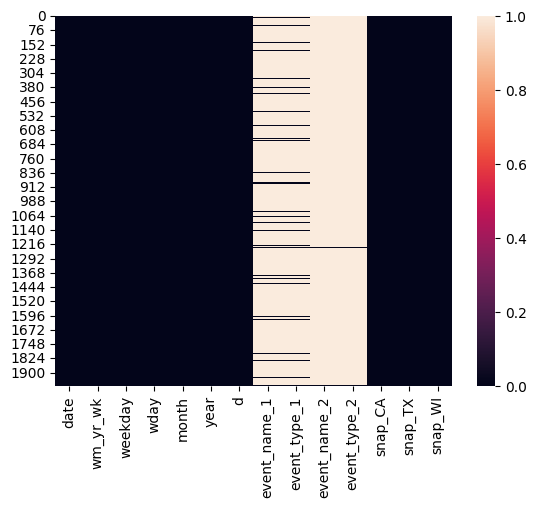

In [40]:
# plot of the dataset where ligth color will be null values
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(calendar_df.isnull())
plt.show()

In [ ]:
calendar_df['year'].value_counts()

year
2012    366
2013    365
2014    365
2015    365
2011    337
2016    171
Name: count, dtype: int64

In [37]:
sales_train_evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [39]:
sales_train_validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


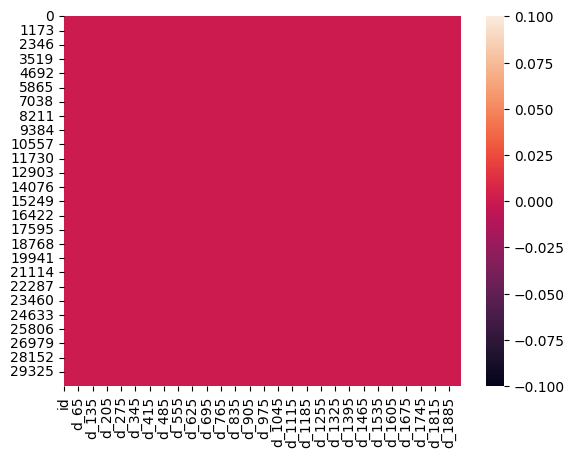

In [44]:
sns.heatmap(sales_train_evaluation_df.isnull())
plt.show()

In [52]:
sales_train_evaluation_df.isnull().sum

<bound method DataFrame.sum of           id  item_id  dept_id  cat_id  store_id  state_id    d_1    d_2  \
0      False    False    False   False     False     False  False  False   
1      False    False    False   False     False     False  False  False   
2      False    False    False   False     False     False  False  False   
3      False    False    False   False     False     False  False  False   
4      False    False    False   False     False     False  False  False   
...      ...      ...      ...     ...       ...       ...    ...    ...   
30485  False    False    False   False     False     False  False  False   
30486  False    False    False   False     False     False  False  False   
30487  False    False    False   False     False     False  False  False   
30488  False    False    False   False     False     False  False  False   
30489  False    False    False   False     False     False  False  False   

         d_3    d_4  ...  d_1932  d_1933  d_1934  d_1935

In [47]:
sample_submission_df.info

<bound method DataFrame.info of                                   id  F1  F2  F3  F4  F5  F6  F7  F8  F9  ...  \
0      HOBBIES_1_001_CA_1_validation   0   0   0   0   0   0   0   0   0  ...   
1      HOBBIES_1_002_CA_1_validation   0   0   0   0   0   0   0   0   0  ...   
2      HOBBIES_1_003_CA_1_validation   0   0   0   0   0   0   0   0   0  ...   
3      HOBBIES_1_004_CA_1_validation   0   0   0   0   0   0   0   0   0  ...   
4      HOBBIES_1_005_CA_1_validation   0   0   0   0   0   0   0   0   0  ...   
...                              ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
60975    FOODS_3_823_WI_3_evaluation   0   0   0   0   0   0   0   0   0  ...   
60976    FOODS_3_824_WI_3_evaluation   0   0   0   0   0   0   0   0   0  ...   
60977    FOODS_3_825_WI_3_evaluation   0   0   0   0   0   0   0   0   0  ...   
60978    FOODS_3_826_WI_3_evaluation   0   0   0   0   0   0   0   0   0  ...   
60979    FOODS_3_827_WI_3_evaluation   0   0   0   0   0   0   0   0   0  ...

In [53]:
sales_train_evaluation_df.describe

<bound method NDFrame.describe of                                   id        item_id    dept_id   cat_id  \
0      HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES   
1      HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES   
2      HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES   
3      HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES   
4      HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES   
...                              ...            ...        ...      ...   
30485    FOODS_3_823_WI_3_evaluation    FOODS_3_823    FOODS_3    FOODS   
30486    FOODS_3_824_WI_3_evaluation    FOODS_3_824    FOODS_3    FOODS   
30487    FOODS_3_825_WI_3_evaluation    FOODS_3_825    FOODS_3    FOODS   
30488    FOODS_3_826_WI_3_evaluation    FOODS_3_826    FOODS_3    FOODS   
30489    FOODS_3_827_WI_3_evaluation    FOODS_3_827    FOODS_3    FOODS   

      store_id state_id  d_1  d_2  d_3  d_4  ...  d_1932  d_1933 